# Dark-State Survival Histogram Analysis

Reload the 10,000-atom dark-state survival histogram from CSV and replot it without rerunning the simulations. Edit the parameters cell to switch between linear/log axes, change time windows, normalize counts, or save a new figure.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.name == "mot_multilevel":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

HISTOGRAM_CSV = PROJECT_ROOT / "outputs/statistics/mot_multilevel/dark_survival_10000/dark_survival_histogram_2us_bins.csv"
PER_ATOM_CSV = PROJECT_ROOT / "outputs/statistics/mot_multilevel/dark_survival_10000/dark_survival_10000_atoms.csv"
DEFAULT_OUTPUT_DIR = PROJECT_ROOT / "outputs/figures/mot_multilevel/dark_survival_10000"

histogram = pd.read_csv(HISTOGRAM_CSV)
atoms = pd.read_csv(PER_ATOM_CSV)
histogram.head()

,bin_start_us,bin_stop_us,count
0,0.0,2.0,339
1,2.0,4.0,372
2,4.0,6.0,326
3,6.0,8.0,329
4,8.0,10.0,295


In [8]:
# Plot controls. Edit these values and rerun the plotting cell.
x_scale = "linear"        # "linear" or "log"
y_scale = "linear"        # "linear" or "log"
normalize = False         # False: counts per bin; True: probability per bin
plot_style = "bar"        # "bar", "step", or "points"
time_min_us = 0.0         # set to None for no lower crop
time_max_us = None        # e.g. 200.0, or None for all bins
count_floor = 0.5         # replacement for zero-count bins on log y-scale
figure_size = (9.5, 5.8)
save_figure = False
output_filename = "dark_survival_histogram_custom.png"

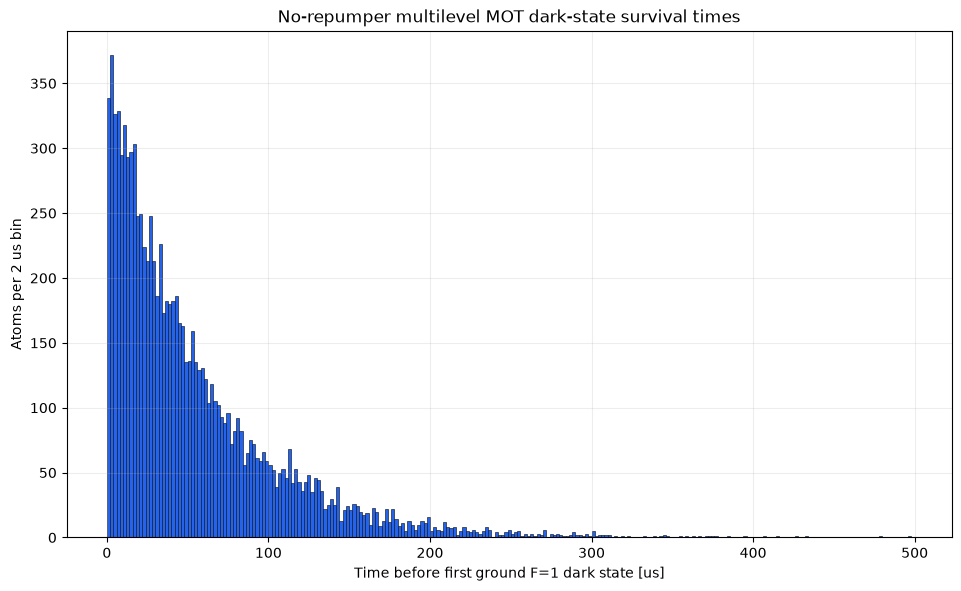

In [10]:
def filtered_histogram(data, time_min_us=None, time_max_us=None):
    selected = data.copy()
    if time_min_us is not None:
        selected = selected[selected["bin_stop_us"] > time_min_us]
    if time_max_us is not None:
        selected = selected[selected["bin_start_us"] < time_max_us]
    return selected.reset_index(drop=True)


def plot_survival_histogram(
    data,
    *,
    x_scale="log",
    y_scale="log",
    normalize=False,
    plot_style="bar",
    count_floor=0.5,
    figure_size=(9.5, 5.8),
):
    if x_scale not in {"linear", "log"}:
        raise ValueError("x_scale must be 'linear' or 'log'")
    if y_scale not in {"linear", "log"}:
        raise ValueError("y_scale must be 'linear' or 'log'")
    if plot_style not in {"bar", "step", "points"}:
        raise ValueError("plot_style must be 'bar', 'step', or 'points'")

    working = data.copy()
    centers = 0.5 * (working["bin_start_us"].to_numpy() + working["bin_stop_us"].to_numpy())
    widths = working["bin_stop_us"].to_numpy() - working["bin_start_us"].to_numpy()
    values = working["count"].to_numpy(dtype=float)
    ylabel = "Atoms per 2 us bin"
    if normalize:
        total = values.sum()
        values = values / total if total > 0 else values
        ylabel = "Probability per 2 us bin"
    if y_scale == "log":
        values = np.where(values > 0.0, values, count_floor)

    figure, axis = plt.subplots(figsize=figure_size, constrained_layout=True)
    if plot_style == "bar":
        axis.bar(centers, values, width=widths, align="center", color="#2563eb", edgecolor="#0f172a", linewidth=0.45)
    elif plot_style == "step":
        edges = np.r_[working["bin_start_us"].to_numpy(), working["bin_stop_us"].iloc[-1]]
        axis.stairs(values, edges, color="#2563eb", linewidth=1.8)
    else:
        axis.plot(centers, values, marker="o", linestyle="", color="#2563eb", markersize=4)

    axis.set_xscale(x_scale)
    axis.set_yscale(y_scale)
    axis.set_xlabel("Time before first ground F=1 dark state [us]")
    axis.set_ylabel(ylabel)
    axis.set_title("No-repumper multilevel MOT dark-state survival times")
    axis.grid(alpha=0.22, which="both")
    return figure, axis


display_data = filtered_histogram(histogram, time_min_us=time_min_us, time_max_us=time_max_us)
figure, axis = plot_survival_histogram(
    display_data,
    x_scale=x_scale,
    y_scale=y_scale,
    normalize=normalize,
    plot_style=plot_style,
    count_floor=count_floor,
    figure_size=figure_size,
)

if save_figure:
    DEFAULT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = DEFAULT_OUTPUT_DIR / output_filename
    figure.savefig(output_path, dpi=180)
    print(output_path)

In [4]:
dark_times_us = atoms["dark_entry_time_us"].dropna().to_numpy(dtype=float)
summary = {
    "atom_count": int(len(atoms)),
    "dark_count": int(len(dark_times_us)),
    "mean_survival_time_us": float(np.mean(dark_times_us)),
    "median_survival_time_us": float(np.median(dark_times_us)),
    "min_survival_time_us": float(np.min(dark_times_us)),
    "max_survival_time_us": float(np.max(dark_times_us)),
}
summary

{'atom_count': 10000,
 'dark_count': 10000,
 'mean_survival_time_us': 53.92969399459305,
 'median_survival_time_us': 37.57735700385851,
 'min_survival_time_us': 0.0434634446251158,
 'max_survival_time_us': 497.8692326181754}